## STEP 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

## STEP 2 — Load & Clean Data

In [2]:
import os

df = pd.read_csv("ML_dataset2.csv")
df.columns = df.columns.str.strip()

# Clean Water Stress
df['Water Stress'] = df['Water Stress'].astype(str).str.replace('* ', '', regex=False)
df['Water Stress'] = pd.to_numeric(df['Water Stress'], errors='coerce')

df = df.dropna(subset=['Population Growth'])
df = df[~df['Year'].isin([2020, 2021])]

print(f'Shape: {df.shape}')
df.head(30)

Shape: (1165, 17)


,Country,Year,Precipitation,River Flow,Soil Water,Surface Water,Terr Water Storage,Vegetation Avg,Water Bodies,Avg Temp,Water Stress,Population Growth,Freshwater Resources,GDP,Overall Water Withdrawals,Dom Wuthdrawls,Political Violence
0,Algeria,2001,52.0,22.998,0.100000,NaN,NaN,0.117250,2099.032,24.18333,81.71,1.373291,358.971009,1776.949446,51.633028,31.40793,155.0
1,Algeria,2002,61.0,20.755,0.103333,NaN,-1.000000,0.115583,1835.018,23.87500,85.04,1.330395,354.226905,1751.911234,53.735272,31.96875,210.0
2,Algeria,2003,99.0,23.075,0.107500,0.000121,2.333333,0.120667,2119.552,23.85833,87.52,1.329615,349.548223,1793.094603,55.305819,32.48746,158.0
3,Algeria,2004,94.0,21.668,0.107500,0.000125,3.000000,0.122333,2149.398,23.51667,90.01,1.396440,344.700914,2116.689481,56.876366,32.96862,96.0
4,Algeria,2005,73.0,21.193,0.105833,0.000080,-6.500000,0.120083,1926.585,23.88333,92.49,1.463309,339.693600,2627.289243,58.446912,33.41618,78.0
5,Algeria,2006,89.0,21.278,0.107500,0.000072,-1.833330,0.121833,1886.113,23.85833,94.98,1.541274,334.498134,3134.549877,60.017459,33.83353,179.0
6,Algeria,2007,72.0,20.138,0.103333,0.000085,-3.333330,0.122500,1928.625,23.75833,97.46,1.669072,328.961454,3504.085461,61.588006,34.22363,302.0
7,Algeria,2008,84.0,24.683,0.110000,0.000146,-10.166700,0.121000,1867.609,23.65000,99.95,1.818853,323.032214,3980.902305,63.158553,34.58906,196.0
8,Algeria,2009,120.0,27.712,0.110833,0.000228,-5.500000,0.128750,2240.138,23.79167,102.44,1.915885,316.902197,4963.688298,64.729100,34.93210,186.0
9,Algeria,2010,73.0,27.015,0.106667,0.000118,-16.250000,0.124750,2286.637,24.96667,104.92,1.947059,310.791606,3916.429087,66.299646,35.25474,107.0


## STEP 3 — Feature Engineering

In [3]:
df_fe = df.copy()

for col in ['River Flow', 'Surface Water', 'Soil Water', 'Avg Temp',
            'Water Stress', 'Freshwater Resources', 'GDP',
            'Overall Water Withdrawals', 'Political Violence']:
    df_fe[col] = pd.to_numeric(df_fe[col], errors='coerce').fillna(0)

# Engineered features
df_fe['water_availability'] = df_fe['River Flow'] + df_fe['Surface Water'] + df_fe['Soil Water']
df_fe['climate_stress']     = df_fe['Avg Temp'] * df_fe['Water Stress']
df_fe['resource_gdp_ratio'] = df_fe['Freshwater Resources'] / (df_fe['GDP'] + 1)
df_fe['human_pressure']     = df_fe['Overall Water Withdrawals'] + df_fe['Political Violence']

## STEP 4 — Define X and y

In [4]:
target = 'Population Growth'

y = df_fe[target]
X = df_fe.drop(columns=[target, 'Year'])

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Features: {X.shape[1]} columns')
print(f'Numeric : {num_cols}')
print(f'Categorical: {cat_cols}')

Features: 19 columns
Numeric : ['Precipitation', 'River Flow', 'Soil Water', 'Surface Water', 'Terr Water Storage', 'Vegetation Avg', 'Water Bodies', 'Avg Temp', 'Water Stress', 'Freshwater Resources', 'GDP', 'Overall Water Withdrawals', 'Dom Wuthdrawls', 'Political Violence', 'water_availability', 'climate_stress', 'resource_gdp_ratio', 'human_pressure']
Categorical: ['Country']


## STEP 5 — Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

Train: 932 rows | Test: 233 rows


## STEP 6 — Preprocessing Pipeline

In [6]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## STEP 7 — Train & Compare All Models

In [7]:
# Define all models to test
models = {
    'Linear Regression'        : LinearRegression(),
    'Ridge Regression'         : Ridge(alpha=1.0),
    'Lasso Regression'         : Lasso(alpha=0.01),
    'Decision Tree'            : DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest'            : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'        : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'                  : XGBRegressor(n_estimators=100, random_state=42,
                                               verbosity=0, eval_metric='rmse')
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    
    pipe.fit(X_train, y_train)
    test_r2 = r2_score(y_test, pipe.predict(X_test))
    test_rmse = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test)))
    
    results[name] = {
        'CV R2 (mean)' : round(cv_scores.mean(), 4),
        'CV R2 (std)'  : round(cv_scores.std(),  4),
        'Test R2'      : round(test_r2,           4),
        'Test RMSE'    : round(test_rmse,          4)
    }
    print(f'{name:<28} | CV R2: {cv_scores.mean():.4f} | Test R2: {test_r2:.4f} | RMSE: {test_rmse:.4f}')

results_df = pd.DataFrame(results).T.sort_values('Test R2', ascending=False)
print('\n--- RESULTS TABLE (sorted by Test R2) ---')
print(results_df)

Linear Regression            | CV R2: 0.6587 | Test R2: 0.0008 | RMSE: 1.2118
Ridge Regression             | CV R2: 0.6629 | Test R2: 0.0400 | RMSE: 1.1878
Lasso Regression             | CV R2: 0.5036 | Test R2: 0.2992 | RMSE: 1.0149
Decision Tree                | CV R2: 0.4697 | Test R2: 0.3350 | RMSE: 0.9886
Random Forest                | CV R2: 0.7403 | Test R2: 0.6890 | RMSE: 0.6761
Gradient Boosting            | CV R2: 0.6841 | Test R2: 0.7061 | RMSE: 0.6573
XGBoost                      | CV R2: 0.7467 | Test R2: 0.7374 | RMSE: 0.6212

--- RESULTS TABLE (sorted by Test R2) ---
                   CV R2 (mean)  CV R2 (std)  Test R2  Test RMSE
XGBoost                  0.7467       0.0329   0.7374     0.6212
Gradient Boosting        0.6841       0.0334   0.7061     0.6573
Random Forest            0.7403       0.0533   0.6890     0.6761
Decision Tree            0.4697       0.0949   0.3350     0.9886
Lasso Regression         0.5036       0.0172   0.2992     1.0149
Ridge Regression     

## STEP 8 — Bar Chart Comparison

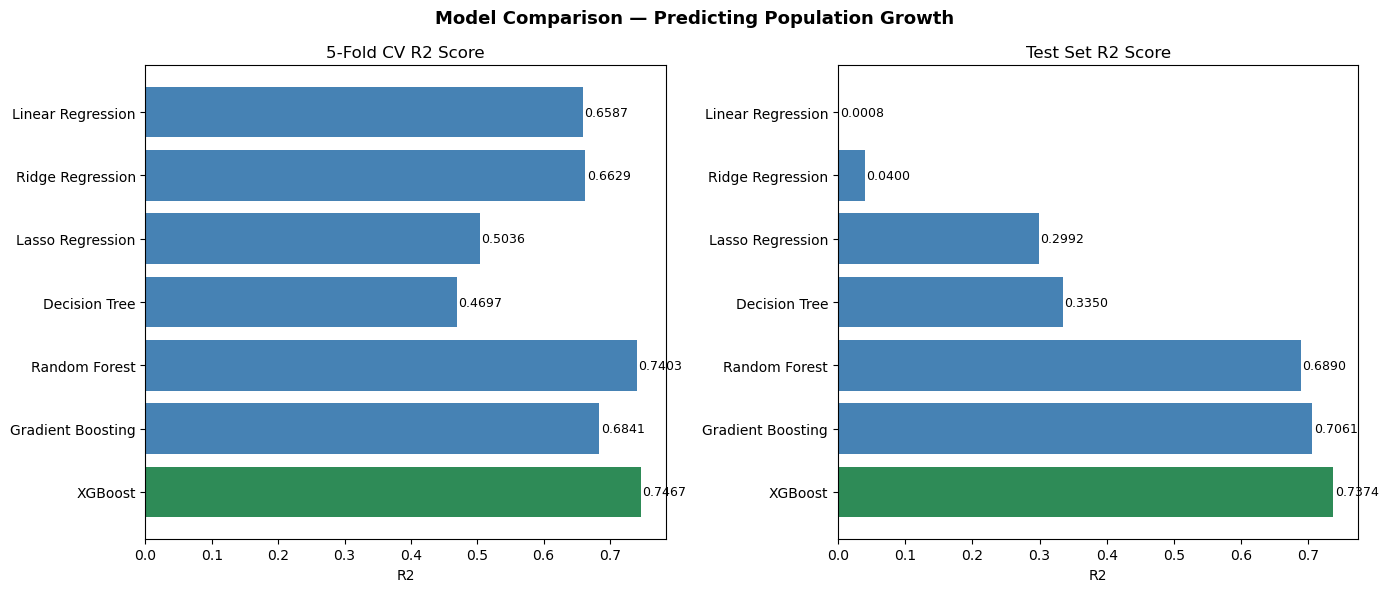


Best model: XGBoost
Test R2   : 0.7374
Test RMSE : 0.6212


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cv_vals  = results_df['CV R2 (mean)'].astype(float)
colors   = ['seagreen' if v == cv_vals.max() else 'steelblue' for v in cv_vals]
axes[0].barh(results_df.index, cv_vals, color=colors)
axes[0].set_title('5-Fold CV R2 Score')
axes[0].set_xlabel('R2')
for i, v in enumerate(cv_vals):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

test_vals = results_df['Test R2'].astype(float)
colors2   = ['seagreen' if v == test_vals.max() else 'steelblue' for v in test_vals]
axes[1].barh(results_df.index, test_vals, color=colors2)
axes[1].set_title('Test Set R2 Score')
axes[1].set_xlabel('R2')
for i, v in enumerate(test_vals):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — Predicting Population Growth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best = results_df['Test R2'].idxmax()
print(f'\nBest model: {best}')
print(f'Test R2   : {results_df.loc[best, "Test R2"]}')
print(f'Test RMSE : {results_df.loc[best, "Test RMSE"]}')

## STEP 9 — Feature Importance (Best Model)

Plotting importance for: XGBoost


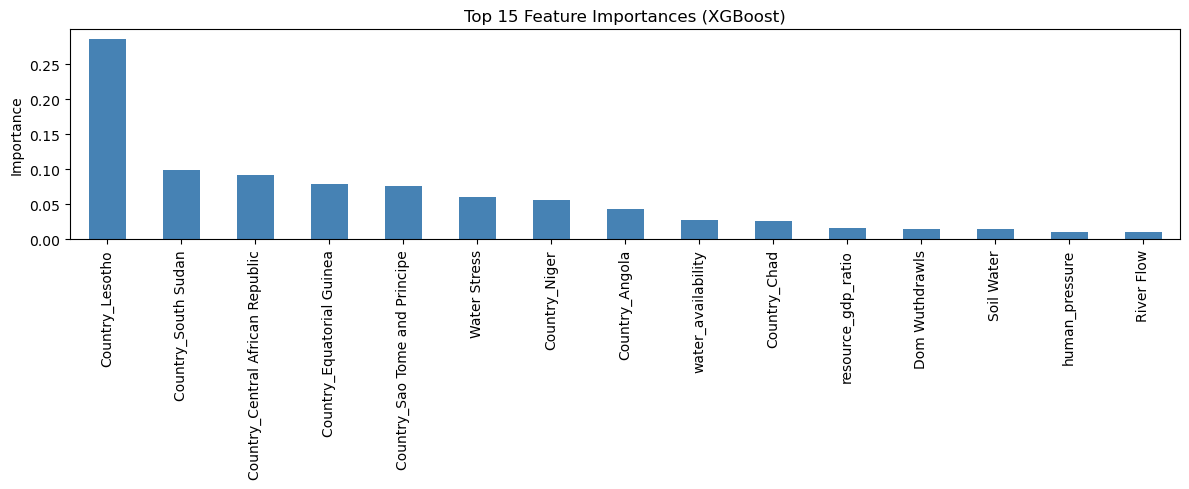


Top 10 features:
Country_Lesotho                     0.285476
Country_South Sudan                 0.099727
Country_Central African Republic    0.091474
Country_Equatorial Guinea           0.078572
Country_Sao Tome and Principe       0.075517
Water Stress                        0.060784
Country_Niger                       0.056372
Country_Angola                      0.043321
water_availability                  0.027729
Country_Chad                        0.026584
dtype: float32


In [9]:
best_model_name = results_df['Test R2'].idxmax()
print(f'Plotting importance for: {best_model_name}')

best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', models[best_model_name])
])
best_pipe.fit(X_train, y_train)

cat_feature_names = (best_pipe.named_steps['preprocessor']
                              .named_transformers_['cat']
                              .named_steps['encoder']
                              .get_feature_names_out(cat_cols).tolist())
all_feature_names = num_cols + cat_feature_names

importances = best_pipe.named_steps['model'].feature_importances_
imp_series  = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

imp_series.head(15).plot(kind='bar', figsize=(12, 5),
                          title=f'Top 15 Feature Importances ({best_model_name})',
                          color='steelblue')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(imp_series.head(10))

## Hyperparamters

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, verbosity=0, eval_metric='rmse'))
])

xgb_params = {
    'model__n_estimators'  : [100, 200, 300],
    'model__max_depth'     : [3, 4, 5, 6],
    'model__learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'model__subsample'     : [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = GridSearchCV(
    xgb_pipe, xgb_params,
    cv=5, scoring='r2',
    n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)

print(f"\nBest XGBoost Params : {xgb_search.best_params_}")
print(f"Best XGBoost CV R2  : {xgb_search.best_score_:.4f}")
print(f"XGBoost Test R2     : {r2_score(y_test, xgb_search.predict(X_test)):.4f}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best XGBoost Params : {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best XGBoost CV R2  : 0.7732
XGBoost Test R2     : 0.7591


In [11]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_params = {
    'model__n_estimators' : [100, 200, 300],
    'model__max_depth'    : [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf' : [1, 2, 4],
    'model__max_features'     : ['sqrt', 'log2', None]
}

rf_search = GridSearchCV(
    rf_pipe, rf_params,
    cv=5, scoring='r2',
    n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)

print(f"\nBest RF Params  : {rf_search.best_params_}")
print(f"Best RF CV R2   : {rf_search.best_score_:.4f}")
print(f"RF Test R2      : {r2_score(y_test, rf_search.predict(X_test)):.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best RF Params  : {'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best RF CV R2   : 0.7627
RF Test R2      : 0.6980


In [12]:
xgb_test_r2 = r2_score(y_test, xgb_search.predict(X_test))
rf_test_r2  = r2_score(y_test, rf_search.predict(X_test))

print("\n--- TUNED RESULTS ---")
print(f"XGBoost Test R2     : {xgb_test_r2:.4f}  (was 0.6794)")
print(f"Random Forest Test R2: {rf_test_r2:.4f}  (was 0.6773)")

winner = "XGBoost" if xgb_test_r2 > rf_test_r2 else "Random Forest"
print(f"\nWinner: {winner}")


--- TUNED RESULTS ---
XGBoost Test R2     : 0.7591  (was 0.6794)
Random Forest Test R2: 0.6980  (was 0.6773)

Winner: XGBoost


## Different Hyperparameter

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# ── XGBoost Extended Tuning ───────────────────────────────────
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, verbosity=0, eval_metric='rmse'))
])

xgb_params = {
    'model__n_estimators'       : [200, 300, 400, 500],
    'model__max_depth'          : [3, 4, 5, 6, 7],
    'model__learning_rate'      : [0.005, 0.01, 0.05, 0.1],
    'model__subsample'          : [0.6, 0.7, 0.8, 0.9],
    'model__colsample_bytree'   : [0.6, 0.7, 0.8, 0.9],
    'model__min_child_weight'   : [1, 3, 5, 7],       # controls overfitting
    'model__gamma'              : [0, 0.1, 0.2, 0.5], # min loss reduction to split
    'model__reg_alpha'          : [0, 0.01, 0.1, 1],  # L1 regularization
    'model__reg_lambda'         : [0.5, 1, 2, 5],     # L2 regularization
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_params,
    n_iter=60,           # try 60 random combos
    cv=5, scoring='r2',
    n_jobs=-1, verbose=1,
    random_state=42
)
xgb_search.fit(X_train, y_train)

xgb_test_r2 = r2_score(y_test, xgb_search.predict(X_test))
print(f"\nBest XGBoost Params : {xgb_search.best_params_}")
print(f"Best XGBoost CV R2  : {xgb_search.best_score_:.4f}")
print(f"XGBoost Test R2     : {xgb_test_r2:.4f}  (was 0.7544)")

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best XGBoost Params : {'model__subsample': 0.9, 'model__reg_lambda': 2, 'model__reg_alpha': 0.1, 'model__n_estimators': 500, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.9}
Best XGBoost CV R2  : 0.7682
XGBoost Test R2     : 0.7541  (was 0.7544)


In [14]:
# ── Random Forest Extended Tuning ────────────────────────────
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_params = {
    'model__n_estimators'      : [200, 300, 400, 500],
    'model__max_depth'         : [None, 10, 20, 30],
    'model__min_samples_split' : [2, 5, 10],
    'model__min_samples_leaf'  : [1, 2, 4],
    'model__max_features'      : ['sqrt', 'log2', None],
    'model__max_samples'       : [0.7, 0.8, 0.9, None],  # bootstrap sample size
    'model__ccp_alpha'         : [0.0, 0.001, 0.01],     # pruning — reduces overfitting
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_params,
    n_iter=60,
    cv=5, scoring='r2',
    n_jobs=-1, verbose=1,
    random_state=42
)
rf_search.fit(X_train, y_train)

rf_test_r2 = r2_score(y_test, rf_search.predict(X_test))
print(f"\nBest RF Params  : {rf_search.best_params_}")
print(f"Best RF CV R2   : {rf_search.best_score_:.4f}")
print(f"RF Test R2      : {rf_test_r2:.4f}  (was 0.7523)")

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best RF Params  : {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_samples': None, 'model__max_features': 'log2', 'model__max_depth': 30, 'model__ccp_alpha': 0.0}
Best RF CV R2   : 0.7459
RF Test R2      : 0.6598  (was 0.7523)


In [15]:
# ── Final Comparison ──────────────────────────────────────────
print("\n--- FINAL TUNED RESULTS ---")
print(f"XGBoost Test R2      : {xgb_test_r2:.4f}  (was 0.7544)")
print(f"Random Forest Test R2: {rf_test_r2:.4f}  (was 0.7523)")

winner = "XGBoost" if xgb_test_r2 > rf_test_r2 else "Random Forest"
print(f"\nWinner: {winner}")


--- FINAL TUNED RESULTS ---
XGBoost Test R2      : 0.7541  (was 0.7544)
Random Forest Test R2: 0.6598  (was 0.7523)

Winner: XGBoost


In [16]:
#get rid of water stress. 
#all and hydro only.